# Regresi Linear

In [55]:
# Libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation

In [56]:
# Data Preparation
df = pd.read_excel("../Data Final/Final_PM16-Facial.xlsx")

Mini Cleaning
df = df[df['MDS'] < 35]
df["GSM"] = pd.to_numeric(df["GSM"])


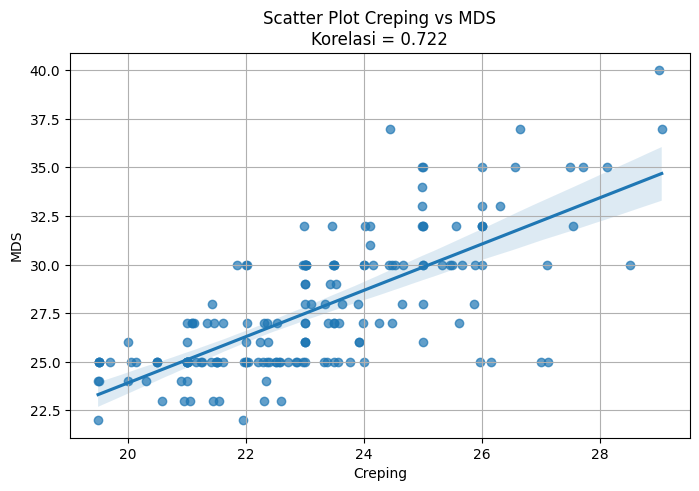

In [57]:
# Hitung korelasi Pearson
corr = df['Mean_Creping'].corr(df['MDS'])

# Plot
plt.figure(figsize=(8,5))

sns.regplot(
    x=df['Mean_Creping'],
    y=df['MDS'],
    scatter_kws={'alpha':0.7}
)

plt.title(f'Scatter Plot Creping vs MDS\nKorelasi = {corr:.3f}')
plt.xlabel('Creping')
plt.ylabel('MDS')

plt.grid(True)
plt.show()

In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 174 entries, 0 to 173
Data columns (total 38 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Start_Time               174 non-null    datetime64[us]
 1   End_Time                 174 non-null    datetime64[us]
 2   Data_Count               174 non-null    int64         
 3   Mean_Creping             174 non-null    float64       
 4   Mean_Yankee Speed        174 non-null    float64       
 5   Mean_Pope Reel Speed     174 non-null    float64       
 6   Mean_Yankee Pressure     174 non-null    float64       
 7   Mean_Stock Flow          174 non-null    float64       
 8   Mean_Stock Consistency   174 non-null    float64       
 9   Mean_Flow Coating        174 non-null    float64       
 10  Mean_Flow Release        174 non-null    float64       
 11  Mean_Jet Wire Ratio      174 non-null    float64       
 12  Mean_Load KWH Refiner    174 non-null    float6

## Modelling Linear Regression

In [59]:
# X Variables 
features = ['Mean_Creping']
X = df[features]

# Y Variables
target = 'MDS'
y = df[target]

In [60]:
# --- OPSI 1: Model Tanpa Intercept (Sesuai kode awal Anda) ---
model_no_const = sm.OLS(y, X).fit()
y_pred_no = model_no_const.predict(X)

mape_no = np.mean(np.abs((y - y_pred_no) / y)) * 100
r2_no = model_no_const.rsquared  # Mengambil R-sq uncentered

print("--- Model Tanpa Intercept ---")
print(f"R-squared: {r2_no:.4f}")
print(f"MAPE: {mape_no:.2f}%")

# --- OPSI 2: Model Dengan Intercept (Disarankan untuk validasi) ---
X_with_const = sm.add_constant(X)
model_with_const = sm.OLS(y, X_with_const).fit()
y_pred_with = model_with_const.predict(X_with_const)

mape_with = np.mean(np.abs((y - y_pred_with) / y)) * 100
r2_with = model_with_const.rsquared # Mengambil R-sq standar

print("\n--- Model Dengan Intercept ---")
print(f"R-squared: {r2_with:.4f}")
print(f"MAPE: {mape_with:.2f}%")

--- Model Tanpa Intercept ---
R-squared: 0.9927
MAPE: 6.70%

--- Model Dengan Intercept ---
R-squared: 0.5219
MAPE: 6.70%


In [61]:
print(model_with_const.summary())

                            OLS Regression Results                            
Dep. Variable:                    MDS   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.519
Method:                 Least Squares   F-statistic:                     187.8
Date:                Fri, 29 May 2026   Prob (F-statistic):           2.28e-29
Time:                        14:21:53   Log-Likelihood:                -397.84
No. Observations:                 174   AIC:                             799.7
Df Residuals:                     172   BIC:                             806.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.1409      2.019      0.070   

In [62]:
print(model_no_const.summary())

                                 OLS Regression Results                                
Dep. Variable:                    MDS   R-squared (uncentered):                   0.993
Model:                            OLS   Adj. R-squared (uncentered):              0.993
Method:                 Least Squares   F-statistic:                          2.359e+04
Date:                Fri, 29 May 2026   Prob (F-statistic):                   7.31e-187
Time:                        14:21:53   Log-Likelihood:                         -397.84
No. Observations:                 174   AIC:                                      797.7
Df Residuals:                     173   BIC:                                      800.8
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

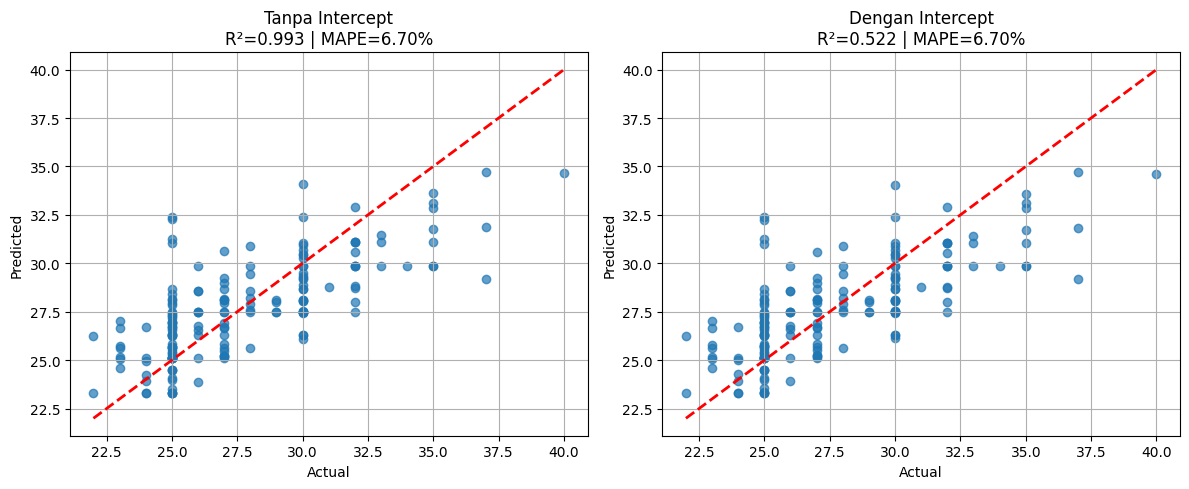

In [63]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

# =========================
# TANPA INTERCEPT
# =========================
ax[0].scatter(y, y_pred_no, alpha=0.7)

ax[0].plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--',
    linewidth=2
)

ax[0].set_title(
    f'Tanpa Intercept\nR²={r2_no:.3f} | MAPE={mape_no:.2f}%'
)

ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Predicted")
ax[0].grid(True)

# =========================
# DENGAN INTERCEPT
# =========================
ax[1].scatter(y, y_pred_with, alpha=0.7)

ax[1].plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    'r--',
    linewidth=2
)

ax[1].set_title(
    f'Dengan Intercept\nR²={r2_with:.3f} | MAPE={mape_with:.2f}%'
)

ax[1].set_xlabel("Actual")
ax[1].set_ylabel("Predicted")
ax[1].grid(True)

plt.tight_layout()
plt.show()

### Import Model

In [64]:
import joblib
import os

# Folder model
#os.makedirs("models/PM14/MDS", exist_ok=True)

# Simpan model
#joblib.dump(model_no_const, "models/PM14/MDS/model.pkl")

# Simpan fitur
#joblib.dump(features, "models/PM14/MDS/features.pkl")

print("Model berhasil disimpan!")

Model berhasil disimpan!


## Pemeriksaan Asumsi IIDN

In [65]:
model = model_with_const

### Independen (Autokorelasi)

In [66]:
DW = sm.stats.durbin_watson(model.resid)
print('Nilai DW =', DW)
if DW > 1.5 and DW < 2.5:
    print('Tidak ada autokorelasi (baik positif maupun negatif)')
elif DW < 1.5:
    print('Terdapat autokorelasi positif.')
elif DW > 2.5:
    print('Terdapat autokorelasi negatif.')

Nilai DW = 1.109920994332063
Terdapat autokorelasi positif.


### Indentik (Heterokesdastisitas)

In [67]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Breusch-Pagan Test
# H0: Homoskedastisitas (Varians konstan)
bp_test = het_breuschpagan(model.resid, model.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']
print(dict(zip(labels, bp_test)))

{'LM Statistic': np.float64(25.096236290260364), 'LM-Test p-value': np.float64(5.453920353249981e-07), 'F-Statistic': np.float64(28.98887532714824), 'F-Test p-value': np.float64(2.3601343980742713e-07)}


Terjadi Heteroskedastisitas yang parah pada model. Varians dari residual terbukti secara empiris tidak konstan.

### Normalitas

In [68]:
# Libraries
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

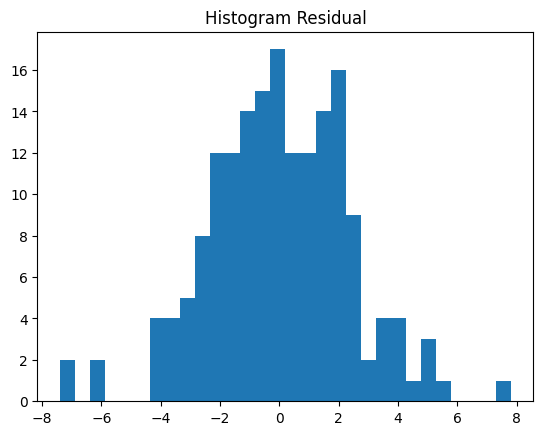

In [69]:
# Histogram
plt.figure()
plt.hist(model.resid, bins=30)
plt.title("Histogram Residual")
plt.show()

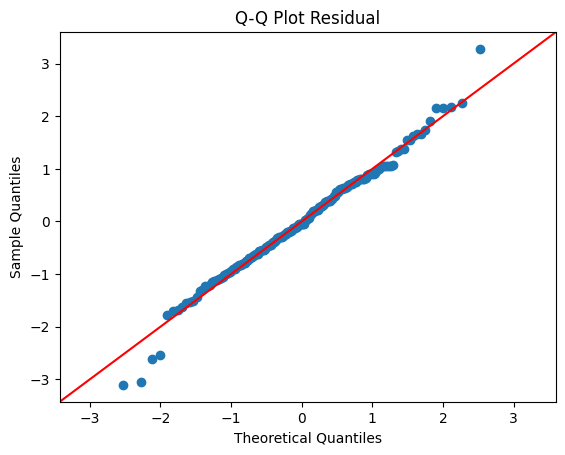

In [70]:
# Visualisasi (Q-Q Plot)
sm.qqplot(model.resid, line='45', fit=True)
plt.title("Q-Q Plot Residual")
plt.show()

In [71]:
# Uji Statistik (Shapiro-Wilk)
# H0: Data berdistribusi normal
# H1: Data tidak berdistribusi normal

stat, p_value = stats.shapiro(model.resid)

# Jika p-value < 0.05, residual tidak berdistribusi normal
print(f"Shapiro-Wilk Test: p-value = {p_value}")
if p_value < 0.05:
    print('residual tidak berdistribusi normal')
else:
    print('residual berdistribusi normal.')

Shapiro-Wilk Test: p-value = 0.24141370436906928
residual berdistribusi normal.


### Multikolinearitas

In [72]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Menghitung VIF untuk setiap variabel independen
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data)

ValueError: zero-size array to reduction operation maximum which has no identity